In [63]:
# Cella 1 - Imports e configurazione
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import csv
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [64]:
# Cella 2 - Config principale (contextual training 2D)
@dataclass
class Config:
    data_dir: Path = Path(".")
    pc_file: str = "PescettiPC.asc"
    bs_file: str = "PescettiBS.asc"
    as_file: str = "PescettiAS.asc"

    # Rapporto verificato: 1000 righe input per 1 riga target.
    stack_size_input: int = 1000
    stack_mode: str = "sum"   # "sum" o "mean"
    input_mode: str = "pc"    # "pc", "bs", "pcbs"

    # Patch 2D
    patch_size: int = 32        # prova 32 o 64
    patch_stride: int = 16
    use_augmentation: bool = True

    # Training
    seed: int = 42
    batch_size: int = 16
    epochs: int = 20
    lr: float = 1e-4
    loss_name: str = "mse"  # "mse" oppure "l1"
    val_split: float = 0.2
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config(data_dir=Path("."))
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)
print(f"Device: {CFG.device}")

Device: cpu


In [65]:
# Cella 3 - DataLoader modulare (immagine 2D completa)
class PescettiDataLoader:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.pc_path = cfg.data_dir / cfg.pc_file
        self.bs_path = cfg.data_dir / cfg.bs_file
        self.as_path = cfg.data_dir / cfg.as_file

    @staticmethod
    def _read_rows(path: Path) -> np.ndarray:
        rows = []
        with path.open("r", newline="") as f:
            reader = csv.reader(f)
            for row in reader:
                vals = [v for v in row if v != ""]
                if len(vals) <= 1:
                    continue
                rows.append(np.array(vals[1:], dtype=np.float32))  # scarto metadato
        if not rows:
            raise ValueError(f"Nessun dato valido letto da {path}")
        return np.stack(rows, axis=0)

    def _stack_input_rows(self, x: np.ndarray, n_target_rows: int) -> np.ndarray:
        n_input_rows, n_pix = x.shape
        k = self.cfg.stack_size_input
        expected = n_target_rows * k
        if n_input_rows != expected:
            raise ValueError(
                f"Input rows={n_input_rows} incompatibile con target rows={n_target_rows} e stack_size={k}"
            )

        # Formato corretto: sequenza temporale di frame completi.
        # x -> (1000 frame, 189 righe, 253 pixel)
        x_blocks = x.reshape(k, n_target_rows, n_pix)
        if self.cfg.stack_mode == "sum":
            return x_blocks.sum(axis=0)
        if self.cfg.stack_mode == "mean":
            return x_blocks.mean(axis=0)
        raise ValueError("stack_mode deve essere 'sum' o 'mean'")

    def load_full_images(self):
        as_img = self._read_rows(self.as_path)   # (189,253)
        pc_rows = self._read_rows(self.pc_path)  # (189000,253)
        bs_rows = self._read_rows(self.bs_path)  # (189000,253)

        if as_img.shape[1] != pc_rows.shape[1] or as_img.shape[1] != bs_rows.shape[1]:
            raise ValueError(
                f"Numero pixel disallineato: AS={as_img.shape[1]} PC={pc_rows.shape[1]} BS={bs_rows.shape[1]}"
            )

        pc_img = self._stack_input_rows(pc_rows, as_img.shape[0])
        bs_img = self._stack_input_rows(bs_rows, as_img.shape[0])

        print(f"AS image shape: {as_img.shape}")
        print(f"PC stacked image shape: {pc_img.shape}")
        print(f"BS stacked image shape: {bs_img.shape}")
        return pc_img, bs_img, as_img

In [66]:
# Cella 4 - PreProcessor modulare
class PreProcessor:
    @staticmethod
    def anscombe(x: np.ndarray) -> np.ndarray:
        # Stabilizzazione varianza per rumore Poisson.
        return 2.0 * np.sqrt(np.clip(x, 0, None) + 3.0 / 8.0)

    @staticmethod
    def minmax_norm(x: np.ndarray, eps: float = 1e-8):
        mn = x.min()
        mx = x.max()
        return (x - mn) / (mx - mn + eps), float(mn), float(mx)

    @staticmethod
    def minmax_apply(x: np.ndarray, mn: float, mx: float, eps: float = 1e-8):
        return (x - mn) / (mx - mn + eps)

In [67]:
# Cella 5 - ModelBuilder (U-Net 2D classica tipo CARE)
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 2, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    @staticmethod
    def _match_size(x: torch.Tensor, ref: torch.Tensor) -> torch.Tensor:
        if x.shape[-2:] != ref.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
        return x

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.outc(d1)

In [68]:
# Cella 6 - Dataset patch 2D con augmentation + SPATIAL SPLIT
class PatchDataset(Dataset):
    def __init__(self, x_img: np.ndarray, y_img: np.ndarray, coords, patch_size: int, augment: bool = False):
        self.x_img = torch.from_numpy(x_img).float()
        self.y_img = torch.from_numpy(y_img).float()
        self.coords = coords
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.coords)

    def _augment_pair(self, x: torch.Tensor, y: torch.Tensor):
        # Rotazioni 90/180/270 e flip orizzontale/verticale applicati in coppia.
        if np.random.rand() < 0.5:
            k = int(np.random.randint(0, 4))
            x = torch.rot90(x, k=k, dims=(0, 1))
            y = torch.rot90(y, k=k, dims=(0, 1))
        if np.random.rand() < 0.5:
            x = torch.flip(x, dims=(1,))
            y = torch.flip(y, dims=(1,))
        if np.random.rand() < 0.5:
            x = torch.flip(x, dims=(0,))
            y = torch.flip(y, dims=(0,))
        return x, y

    def __getitem__(self, idx):
        r0, c0 = self.coords[idx]
        ps = self.patch_size
        x_patch = self.x_img[r0:r0 + ps, c0:c0 + ps]
        y_patch = self.y_img[r0:r0 + ps, c0:c0 + ps]

        if self.augment:
            x_patch, y_patch = self._augment_pair(x_patch, y_patch)

        return x_patch.unsqueeze(0), y_patch.unsqueeze(0)  # [1,ps,ps]


def generate_patch_coords_in_row_range(h: int, w: int, ps: int, stride: int, row_start: int, row_end_exclusive: int):
    # Crea patch SOLO nella finestra verticale [row_start, row_end_exclusive).
    local_h = row_end_exclusive - row_start
    if local_h < ps:
        raise ValueError(f"Area righe troppo piccola per patch_size={ps}: {local_h}")

    rows_local = list(range(0, local_h - ps + 1, stride))
    cols = list(range(0, w - ps + 1, stride))
    if rows_local[-1] != local_h - ps:
        rows_local.append(local_h - ps)
    if cols[-1] != w - ps:
        cols.append(w - ps)

    # Trasla le coordinate locali sul sistema globale dell'immagine intera.
    rows_global = [row_start + r for r in rows_local]
    return [(r, c) for r in rows_global for c in cols]


loader = PescettiDataLoader(CFG)
pc_img, bs_img, as_img = loader.load_full_images()

if CFG.input_mode.lower() == "pc":
    x_raw = pc_img
elif CFG.input_mode.lower() == "bs":
    x_raw = bs_img
elif CFG.input_mode.lower() == "pcbs":
    x_raw = 0.5 * (pc_img + bs_img)
else:
    raise ValueError("input_mode deve essere 'pc', 'bs' o 'pcbs'")

y_raw = as_img

# Anscombe PRIMA della normalizzazione [0,1]
x_ans = PreProcessor.anscombe(x_raw)
x_norm, x_min, x_max = PreProcessor.minmax_norm(x_ans)
y_norm, y_min, y_max = PreProcessor.minmax_norm(y_raw)

H, W = x_norm.shape
split_row = 95  # train: 0..94, val/test: 95..188

# Split spaziale netto (no random_split).
train_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=split_row)
val_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=split_row, row_end_exclusive=H)
coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=H)

train_dataset = PatchDataset(x_norm, y_norm, train_coords, CFG.patch_size, augment=CFG.use_augmentation)
val_dataset = PatchDataset(x_norm, y_norm, val_coords, CFG.patch_size, augment=False)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

xb0, yb0 = next(iter(train_loader))
print(f"Full image shape: {(H, W)}")
print(f"Spatial split row: {split_row} (train 0..{split_row-1}, val/test {split_row}..{H-1})")
print(f"Patch count: total={len(coords)} train={len(train_dataset)} val={len(val_dataset)}")
print(f"Batch debug shape -> xb: {tuple(xb0.shape)}, yb: {tuple(yb0.shape)}")

AS image shape: (189, 253)
PC stacked image shape: (189, 253)
BS stacked image shape: (189, 253)
Full image shape: (189, 253)
Patch count: total=165 train=132 val=33
Batch debug shape -> xb: (16, 1, 32, 32), yb: (16, 1, 32, 32)


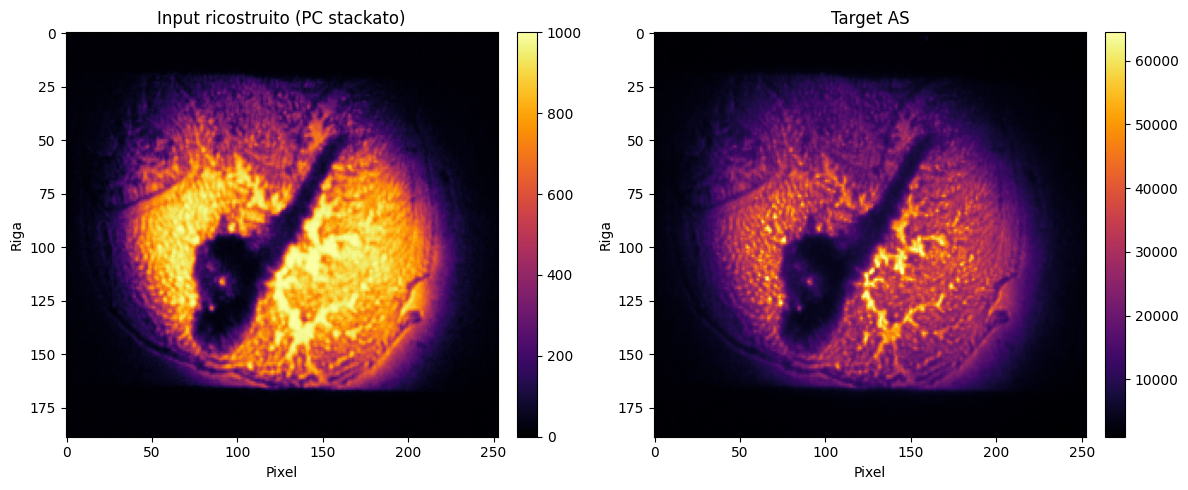

STOP prima della U-Net: verificare coerenza spaziale dell'input stackato.


In [69]:
# Cella 7 - STOP: visualizzazione input ricostruito prima della U-Net
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(x_raw, cmap="inferno", aspect="auto")
ax[0].set_title(f"Input ricostruito ({CFG.input_mode.upper()} stackato)")
ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Riga")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(y_raw, cmap="inferno", aspect="auto")
ax[1].set_title("Target AS")
ax[1].set_xlabel("Pixel")
ax[1].set_ylabel("Riga")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("STOP prima della U-Net: verificare coerenza spaziale dell'input stackato.")

In [70]:
# Cella 8 - Trainer 2D
def build_loss(loss_name: str):
    loss_name = loss_name.lower()
    if loss_name == "mse":
        return nn.MSELoss()
    if loss_name == "l1":
        return nn.L1Loss()
    raise ValueError("loss_name deve essere 'mse' o 'l1'")


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            bs = xb.shape[0]
            total += loss.item() * bs
            n += bs
    return total / max(n, 1)


model = UNet2D(in_ch=1, out_ch=1, base=32).to(CFG.device)
criterion = build_loss(CFG.loss_name)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, CFG.epochs + 1):
    model.train()
    running = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.shape[0]
        running += loss.item() * bs
        seen += bs

    train_loss = running / max(seen, 1)
    val_loss = evaluate(model, val_loader, criterion, CFG.device)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:03d}/{CFG.epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

Epoch 001/20 | train=0.157145 | val=0.053951
Epoch 002/20 | train=0.066048 | val=0.029716
Epoch 003/20 | train=0.035024 | val=0.017272
Epoch 004/20 | train=0.021384 | val=0.015153
Epoch 005/20 | train=0.014950 | val=0.013431
Epoch 006/20 | train=0.011014 | val=0.008785
Epoch 007/20 | train=0.008800 | val=0.007120
Epoch 008/20 | train=0.009623 | val=0.007006
Epoch 009/20 | train=0.007395 | val=0.006236
Epoch 010/20 | train=0.007157 | val=0.006231
Epoch 011/20 | train=0.009103 | val=0.005506
Epoch 012/20 | train=0.006553 | val=0.005726
Epoch 013/20 | train=0.006943 | val=0.005192
Epoch 014/20 | train=0.007711 | val=0.004997
Epoch 015/20 | train=0.005789 | val=0.005748
Epoch 016/20 | train=0.005492 | val=0.004456
Epoch 017/20 | train=0.005473 | val=0.004325
Epoch 018/20 | train=0.005993 | val=0.003940
Epoch 019/20 | train=0.005431 | val=0.003629
Epoch 020/20 | train=0.004586 | val=0.003582


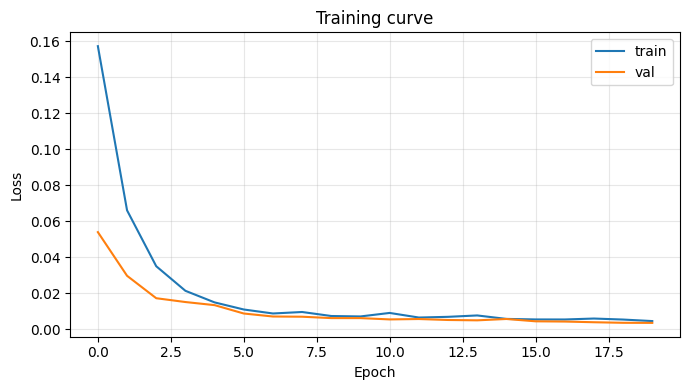

recon_input shape: (189, 253)
recon_pred shape: (189, 253)
recon_gt shape: (189, 253)


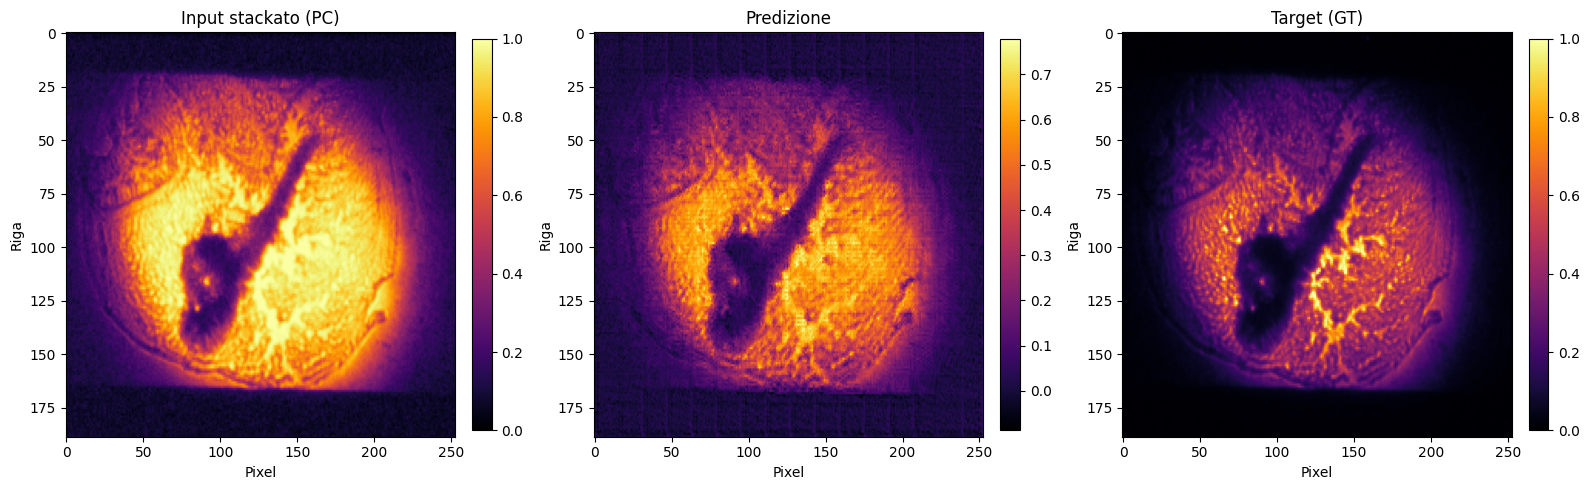

In [71]:
# Cella 9 - Plot curve + ricostruzione full image con confine train/test
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training curve (spatial split)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Ricostruzione dell'immagine 189x253 con media su patch sovrapposte.
model.eval()
acc = np.zeros((H, W), dtype=np.float32)
cnt = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():
    for (r0, c0) in coords:
        x_patch = x_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
        xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)  # [1,1,ps,ps]
        pred = model(xb).cpu().numpy()[0, 0]
        acc[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred
        cnt[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

recon_input = x_norm
recon_pred = acc / np.maximum(cnt, 1e-8)
recon_gt = y_norm

print(f"recon_input shape: {recon_input.shape}")
print(f"recon_pred shape: {recon_pred.shape}")
print(f"recon_gt shape: {recon_gt.shape}")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
im0 = ax[0].imshow(recon_input, cmap="inferno", aspect="auto")
ax[0].set_title("Input stackato (PC)")
ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Riga")
ax[0].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[0].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[0].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(recon_pred, cmap="inferno", aspect="auto")
ax[1].set_title("Predizione")
ax[1].set_xlabel("Pixel")
ax[1].set_ylabel("Riga")
ax[1].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[1].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[1].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(recon_gt, cmap="inferno", aspect="auto")
ax[2].set_title("Target (GT)")
ax[2].set_xlabel("Pixel")
ax[2].set_ylabel("Riga")
ax[2].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[2].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[2].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# Cella 10 - Metriche quantitative su TEST AREA (PSNR / SSIM)
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

split_row = 95  # test area: 95..188

test_input = recon_input[split_row:, :]
test_pred = recon_pred[split_row:, :]
test_gt = recon_gt[split_row:, :]

psnr_input = peak_signal_noise_ratio(test_gt, test_input, data_range=1.0)
ssim_input = structural_similarity(test_gt, test_input, data_range=1.0)

psnr_pred = peak_signal_noise_ratio(test_gt, test_pred, data_range=1.0)
ssim_pred = structural_similarity(test_gt, test_pred, data_range=1.0)

print("=== TEST AREA METRICS (rows 95-188) ===")
print(f"Input  vs GT -> PSNR: {psnr_input:.4f} dB | SSIM: {ssim_input:.6f}")
print(f"Pred   vs GT -> PSNR: {psnr_pred:.4f} dB | SSIM: {ssim_pred:.6f}")
print("--- Delta improvement (Pred - Input) ---")
print(f"Delta PSNR: {psnr_pred - psnr_input:+.4f} dB")
print(f"Delta SSIM: {ssim_pred - ssim_input:+.6f}")

In [ ]:
# Cella 11 - Studio di ablazione: inferenza incrementale su numero di frame
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

frame_steps = [10, 50, 100, 200, 500, 1000]

# Carica PC raw e ricostruisce il tensore temporale [1000, 189, 253]
pc_rows_raw = loader._read_rows(loader.pc_path)  # [189000, 253]
k_total = CFG.stack_size_input
if pc_rows_raw.shape[0] != k_total * H:
    raise ValueError(f"PC raw rows inattese: {pc_rows_raw.shape[0]} vs {k_total * H}")
pc_frames = pc_rows_raw.reshape(k_total, H, W)   # [1000, 189, 253]

# Ground Truth normalizzata (coerente con training/test)
gt_full = y_norm
gt_test = gt_full[split_row:, :]

results = []
pred_map_by_n = {}

model.eval()
with torch.no_grad():
    for N in frame_steps:
        # Stacking sui primi N frame: [:N, :, :]
        x_sim_raw = pc_frames[:N, :, :].sum(axis=0)  # [189,253]

        # Stesso preprocessing del test: Anscombe + MinMax con scaler del training
        x_sim_ans = PreProcessor.anscombe(x_sim_raw)
        x_sim_norm = PreProcessor.minmax_apply(x_sim_ans, x_min, x_max)

        # Ricostruzione full image via patch overlap-average
        acc_sim = np.zeros((H, W), dtype=np.float32)
        cnt_sim = np.zeros((H, W), dtype=np.float32)

        for (r0, c0) in coords:
            x_patch = x_sim_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            pred_patch = model(xb).cpu().numpy()[0, 0]
            acc_sim[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred_patch
            cnt_sim[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

        recon_sim = acc_sim / np.maximum(cnt_sim, 1e-8)
        pred_map_by_n[N] = recon_sim

        # Metriche sulla SOLA Test Area (righe 95..188)
        pred_test = recon_sim[split_row:, :]
        psnr = peak_signal_noise_ratio(gt_test, pred_test, data_range=1.0)
        ssim = structural_similarity(gt_test, pred_test, data_range=1.0)

        results.append({"N": N, "PSNR": psnr, "SSIM": ssim})

# Tabella risultati
print("=== Ablation results on TEST AREA (rows 95-188) ===")
for r in results:
    print(f"N={r['N']:4d} | PSNR={r['PSNR']:.4f} dB | SSIM={r['SSIM']:.6f}")

# Plot 1: curve PSNR/SSIM vs N
N_vals = [r["N"] for r in results]
psnr_vals = [r["PSNR"] for r in results]
ssim_vals = [r["SSIM"] for r in results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(N_vals, psnr_vals, marker="o", label="PSNR (dB)")
ax1.set_xlabel("Numero di frame (N)")
ax1.set_ylabel("PSNR (dB)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(N_vals, ssim_vals, marker="s", linestyle="--", label="SSIM", color="tab:orange")
ax2.set_ylabel("SSIM")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.title("Ablation: prestazione vs numero frame")
plt.tight_layout()
plt.show()

# Plot 2: confronto visivo Test Area per N=50,200,1000 + GT
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for j, N in enumerate([50, 200, 1000]):
    im = ax[j].imshow(pred_map_by_n[N][split_row:, :], cmap="inferno", aspect="auto")
    ax[j].set_title(f"Pred test area (N={N})")
    ax[j].set_xlabel("Pixel")
    ax[j].set_ylabel("Riga test")
    plt.colorbar(im, ax=ax[j], fraction=0.046, pad=0.04)

im_gt = ax[3].imshow(gt_test, cmap="inferno", aspect="auto")
ax[3].set_title("Ground Truth test area")
ax[3].set_xlabel("Pixel")
ax[3].set_ylabel("Riga test")
plt.colorbar(im_gt, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()